# Homework Starter — Stage 10b: Time Series & Classification
Fill in the TODOs. Use your own project dataset or adapt the synthetic generator below.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# Imports
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
np.random.seed(7); sns.set(); plt.rcParams['figure.figsize']=(9,4)

## Synthetic Generator 

In [3]:
# Synthetic series with regimes & jumps
n=500
dates=pd.bdate_range('2021-01-01', periods=n)
mu = np.where(np.arange(n)<n//2, 0.0003, -0.0001)
sigma = np.where(np.arange(n)<n//2, 0.01, 0.015)
eps = np.random.normal(mu, sigma)
jumps = np.zeros(n); jump_days = np.random.choice(np.arange(20,n-20), size=5, replace=False)
jumps[jump_days] = np.random.normal(0,0.05,size=len(jump_days))
rets = eps + jumps
price = 100*np.exp(np.cumsum(rets))
df = pd.DataFrame({'price':price}, index=dates)
df['ret'] = df['price'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])
df.head()

,price,ret,log_ret
2021-01-01,101.735412,0.000000,0.000000
2021-01-04,101.292875,-0.004350,-0.004359
2021-01-05,101.356527,0.000628,0.000628
2021-01-06,101.800950,0.004385,0.004375
2021-01-07,101.031283,-0.007561,-0.007589


In [4]:
print(df.index)

print("\nIndex type:")
print(type(df.index))

DatetimeIndex(['2021-01-01', '2021-01-04', '2021-01-05', '2021-01-06',
               '2021-01-07', '2021-01-08', '2021-01-11', '2021-01-12',
               '2021-01-13', '2021-01-14',
               ...
               '2022-11-18', '2022-11-21', '2022-11-22', '2022-11-23',
               '2022-11-24', '2022-11-25', '2022-11-28', '2022-11-29',
               '2022-11-30', '2022-12-01'],
              dtype='datetime64[ns]', length=500, freq='B')

Index type:
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [5]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (500, 3)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 2021-01-01 to 2022-12-01
Freq: B
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   price    500 non-null    float64
 1   ret      500 non-null    float64
 2   log_ret  500 non-null    float64
dtypes: float64(3)
memory usage: 15.6 KB


,price,ret,log_ret
count,500.000000,500.000000,500.000000
mean,78.775952,-0.001144,-0.001240
std,14.325033,0.013793,0.013900
min,54.065523,-0.080181,-0.083578
25%,67.076746,-0.008918,-0.008958
50%,78.053404,-0.000941,-0.000941
75%,91.119865,0.007302,0.007275
max,102.106835,0.043746,0.042816


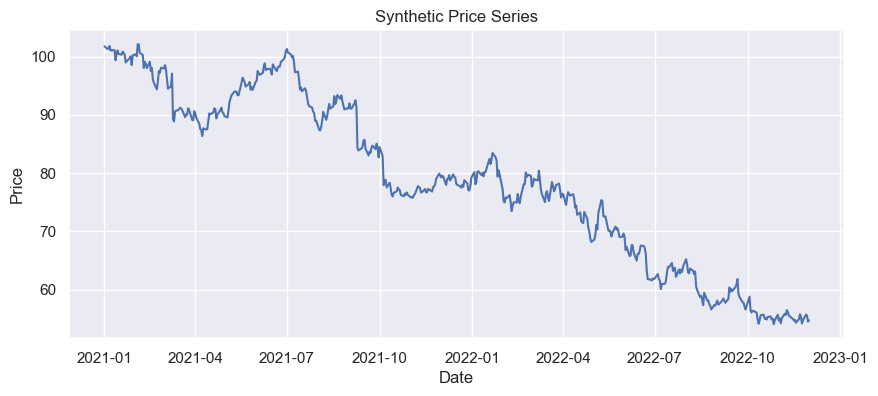

In [6]:
plt.figure(figsize=(10, 4))

plt.plot(
    df.index,
    df["price"]
)

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Synthetic Price Series")

plt.show()

### Data Description

The dataset contains 500 business-day observations of a synthetic financial price series.

The synthetic process contains different volatility regimes and several large jumps, which makes the series more realistic than a constant-distribution process.

Daily simple returns are calculated from prices and will be used to construct predictive features.

## Feature Engineering

In [7]:
# TODO: create at least two features
df['lag_1'] = df['ret'].shift(1)
df["lag_2"] = df["ret"].shift(2)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)
df['roll_vol_20'] = df['ret'].rolling(20).std().shift(1)
df["momentum_5"] = df["price"].pct_change(5).shift(1)
df['y_next_ret'] = df['ret'].shift(-1)
df['y_up'] = (df['y_next_ret']>0).astype(int)
df.loc[df["y_next_ret"].isna(),"y_up"] = np.nan
df_feat = df.dropna().copy()
df_feat["y_up"] = (df_feat["y_up"].astype(int))
df_feat.head()

,price,ret,log_ret,lag_1,lag_2,roll_mean_5,roll_vol_20,momentum_5,y_next_ret,y_up
2021-01-29,100.198878,0.016949,0.016807,-0.014854,0.003049,-0.003707,0.007370,-0.018593,0.001845,1
2021-02-01,100.383751,0.001845,0.001843,0.016949,-0.014854,0.002509,0.008455,0.012347,-0.003565,0
2021-02-02,100.025880,-0.003565,-0.003571,0.001845,0.016949,0.001706,0.008429,0.008303,0.020804,1
2021-02-03,102.106835,0.020804,0.020591,-0.003565,0.001845,0.000685,0.008453,0.003163,-0.000154,0
2021-02-04,102.091126,-0.000154,-0.000154,0.020804,-0.003565,0.004236,0.009675,0.020920,-0.014106,0


### Leakage Prevention

All lagged and rolling features use only information that would have been available before the prediction time.

The lag features explicitly use previous-period returns, while rolling statistics and momentum are shifted by one period. Therefore, the features do not use future information when predicting the next-period direction.

In [8]:
feature_cols = [
    "lag_1",
    "lag_2",
    "roll_mean_5",
    "roll_vol_20",
    "momentum_5"
]

df_feat[
    feature_cols
    + ["y_next_ret", "y_up"]
].head()

,lag_1,lag_2,roll_mean_5,roll_vol_20,momentum_5,y_next_ret,y_up
2021-01-29,-0.014854,0.003049,-0.003707,0.007370,-0.018593,0.001845,1
2021-02-01,0.016949,-0.014854,0.002509,0.008455,0.012347,-0.003565,0
2021-02-02,0.001845,0.016949,0.001706,0.008429,0.008303,0.020804,1
2021-02-03,-0.003565,0.001845,0.000685,0.008453,0.003163,-0.000154,0
2021-02-04,0.020804,-0.003565,0.004236,0.009675,0.020920,-0.014106,0


In [9]:
df_feat[
    feature_cols
].isna().sum()

lag_1          0
lag_2          0
roll_mean_5    0
roll_vol_20    0
momentum_5     0
dtype: int64

In [10]:
df_feat["y_up"].value_counts()

y_up
0    259
1    220
Name: count, dtype: int64

In [11]:
df_feat["y_up"].value_counts(
    normalize=True
)

y_up
0    0.54071
1    0.45929
Name: proportion, dtype: float64

## Target

The classification target is `y_up`.

`y_up = 1` indicates that the next-period return is positive, while `y_up = 0` indicates that the next-period return is zero or negative.

The target is created using `ret.shift(-1)`, so the model attempts to predict the direction of the next observation.

## Split

In [12]:
# Time-aware split
cut=int(len(df_feat)*0.8)
train = df_feat.iloc[:cut].copy()
test = df_feat.iloc[cut:].copy()
features = [
    "lag_1",
    "lag_2",
    "roll_mean_5",
    "roll_vol_20",
    "momentum_5"
]
X_train = train[features]
X_test = test[features]
y_train = train["y_up"]
y_test = test["y_up"]

In [13]:
print(
    "Training period:",
    train.index.min(),
    "to",
    train.index.max()
)

print(
    "Testing period:",
    test.index.min(),
    "to",
    test.index.max()
)

print()

print(
    "Training observations:",
    len(train)
)

print(
    "Testing observations:",
    len(test)
)

Training period: 2021-01-29 00:00:00 to 2022-07-19 00:00:00
Testing period: 2022-07-20 00:00:00 to 2022-11-30 00:00:00

Training observations: 383
Testing observations: 96


### Split Strategy

Because this is a time-series prediction problem, I use the earliest 80% of observations as the training set and the most recent 20% as the test set.

I do not randomly shuffle the observations because doing so could allow information from later dates to influence training and would produce an unrealistic evaluation of future predictions.

## Pipeline + Model (Choose one track below)

In [14]:
clf = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logit",
        LogisticRegression(
            max_iter=1000,
            random_state=7
        )
    )
])
clf.fit(
    X_train,
    y_train
)
y_pred = clf.predict(
    X_test
)
y_prob = clf.predict_proba(
    X_test
)[:, 1]

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.5521
Precision: 0.5000
Recall:    0.2791
F1 Score:  0.3582


In [16]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.57      0.77      0.66        53
           1       0.50      0.28      0.36        43

    accuracy                           0.55        96
   macro avg       0.53      0.53      0.51        96
weighted avg       0.54      0.55      0.52        96



In [17]:
metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_table

,Metric,Value
0,Accuracy,0.552083
1,Precision,0.500000
2,Recall,0.279070
3,F1,0.358209


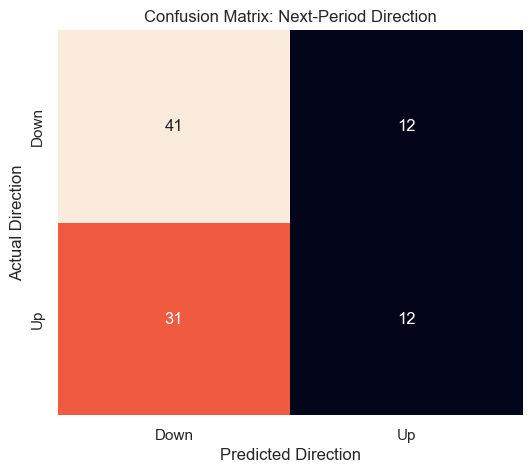

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["Down", "Up"],
    yticklabels=["Down", "Up"]
)

plt.xlabel("Predicted Direction")

plt.ylabel("Actual Direction")

plt.title(
    "Confusion Matrix: Next-Period Direction"
)

plt.show()

In [20]:
results = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": y_pred
    },
    index=y_test.index
)

results.head()

,Actual,Predicted
2022-07-20,1,0
2022-07-21,0,0
2022-07-22,1,0
2022-07-25,0,1
2022-07-26,1,0


## Interpretation

- **What worked?**  
  The time-aware modeling workflow worked as intended. The lagged, rolling, and momentum features were constructed using only past information, which helps avoid data leakage. The sklearn Pipeline also combines feature scaling and logistic regression in a reproducible way. On the test set, the model achieved an accuracy of approximately 55.2%. This indicates that the model captures a small amount of directional information, although the predictive performance is still limited.

- **Where might assumptions fail?**  
  Logistic regression assumes a relatively stable relationship between the predictors and the probability of an upward return. However, financial returns are noisy and may experience regime changes, jumps, and changing volatility. These effects can make the relationship between historical features and future direction unstable over time. The model also has relatively low recall for the positive class (about 27.9%), meaning that it misses many actual upward movements. Therefore, accuracy alone may overstate the usefulness of the classifier.

- **How would you extend features or model?**  
  I would add more time-series features, such as longer-horizon lagged returns, rolling z-scores, additional momentum measures, and rolling minimum/maximum features. I would also evaluate the model using `TimeSeriesSplit` and compare logistic regression with nonlinear models such as decision trees or ensemble methods. These extensions could help capture relationships that a simple linear classifier may miss.